# Pseudobulk Enrichment Analysis
https://decoupler.readthedocs.io/en/latest/notebooks/scell/rna_psbk.html

For when cell clusters are very well defined, and also for when we have multiple samples in the experiment too. Pseudobulking helps mitigate the effects of noise that can present itself in individual cell measurements. Additionally, statistics using pseudobulk is more robust.

For this tutorial, let's infer TF and pathway enrichments from a multi-sample scRNAseq dataset. It includes 5k PBMCs from both healthy and COVID-10 infected patients.

In [66]:
import numpy as np
import scanpy as sc
import decoupler as dc
import anndata as ad
import pandas as pd

Using decoupler API to retrieve the covid5k data resulted in an error 404, so I downloaded the entire project file (h5ad) and aim to extract only the data necessary for this tutorial

In [2]:
# adata = dc.ds.covid5k(verbose=True) # we love error 404s! :(
adata = sc.read_h5ad("data/covid5k/E-MTAB-9221.project.h5ad")
adata

AnnData object with n_obs × n_vars = 6807 × 20522
    obs: 'age', 'clinical_history', 'developmental_stage', 'disease', 'individual', 'organism_part', 'organism', 'sex', 'authors_cell_type_-_ontology_labels', 'clinical_history.1', 'disease.1', 'sampling_time_point', 'age_ontology', 'clinical_history_ontology', 'developmental_stage_ontology', 'disease_ontology', 'individual_ontology', 'organism_part_ontology', 'organism_ontology', 'sex_ontology', 'authors_cell_type_-_ontology_labels_ontology', 'clinical_history_ontology.1', 'disease_ontology.1', 'sampling_time_point_ontology', 'doublet_score', 'predicted_doublet', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'n_counts', 'n_genes', 'louvain_resolution_0.1', 'louvain_resolution_0.3', 'louvain_resolution_0.5', 'louvain_resolution_0.7', 'louvain_resolution_1.0', 'louvain_resolution_2.0', 'louvain_resolution_3.0', 'louvain_resolution_4

In [3]:
# Unsure whether 'filtered' counts retained the raw gene counts after filtering, but it's all I have to work with
# for the purposes of this tutorial
adata.X = adata.layers['filtered'].astype(int)

# Subset the finished adata into what the tutorial starts with
obs = adata.obs[['individual', 'sex', 'disease', 'authors_cell_type_-_ontology_labels']]
obsm = {'X_umap': adata.obsm['X_umap_neighbors_n_neighbors_15']} # let's just use the scanpy default of n_neighbors=15
var = adata.var[['gene_symbols', 'gene_name']]

adata_b = ad.AnnData(
    X=adata.X,
    obs=obs,
    obsm=obsm,
    var=var
)

# adata_b.var_names = adata_b.var['gene_symbols']

adata_b

AnnData object with n_obs × n_vars = 6807 × 20522
    obs: 'individual', 'sex', 'disease', 'authors_cell_type_-_ontology_labels'
    var: 'gene_symbols', 'gene_name'
    obsm: 'X_umap'
    layers: None (.X)

In [4]:
var_names = []
for ix, x in zip(adata_b.var['gene_symbols'].astype(str).fillna('0').index, adata_b.var['gene_symbols'].astype(str).fillna('0').values):
    if x != '0':
        var_names += [x]
    else:
        var_names += [ix]

adata_b.var_names = var_names
adata_b.var_names_make_unique()

Drop all cells that did not have a final annotation by the authors.

In [5]:
adata_b = adata_b[adata_b.obs['authors_cell_type_-_ontology_labels'].dropna().index, :]
adata_b.obs = adata_b.obs.rename(columns={'authors_cell_type_-_ontology_labels': 'celltype'})

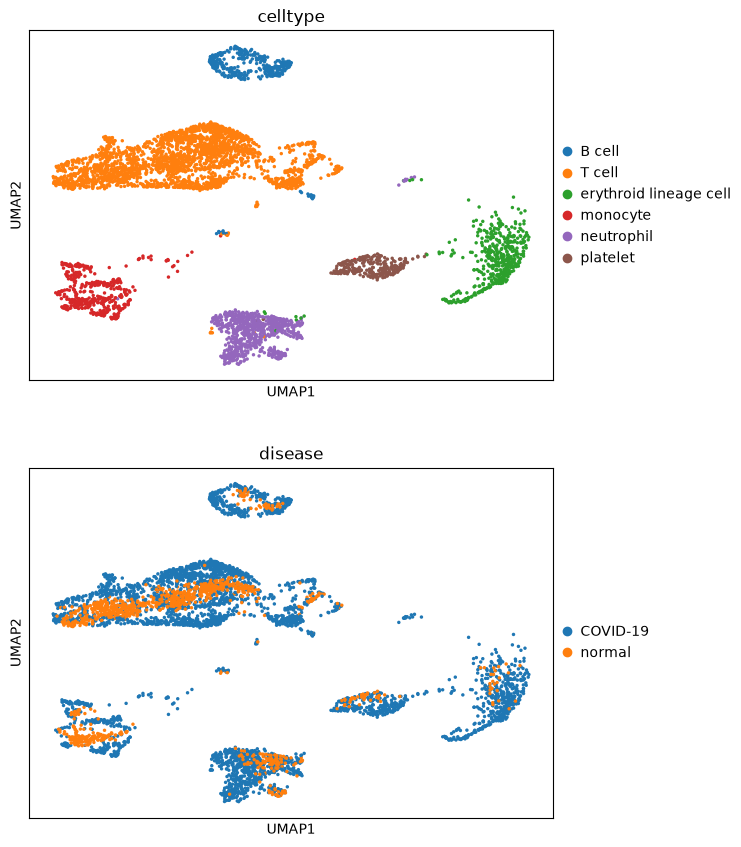

In [6]:
sc.pl.umap(adata_b, color=['celltype', 'disease'], ncols=1)

## Time to pseudobulk!
Pseudobulking involves first subsetting the cell type/condition of interest. Then we their gene counts into a single profile.

In [7]:
pdata = dc.pp.pseudobulk( # here, we're grouping by both sample and annotated celltype
    adata_b,
    sample_col='individual',
    groups_col='celltype',
    mode='sum' # just to try it out, let's do mean
)

In [34]:
pdata.obs

,individual,celltype,sex,disease,psbulk_cells,psbulk_counts
Control #1_B cell,Control #1,B cell,female,normal,10.0,80000.0
Control #2_B cell,Control #2,B cell,female,normal,17.0,139442.0
Control #3_B cell,Control #3,B cell,female,normal,20.0,153069.0
SARS-CoV2 pos Mild_B cell,SARS-CoV2 pos Mild,B cell,female,COVID-19,85.0,561997.0
SARS-CoV2 pos Severe #1_B cell,SARS-CoV2 pos Severe #1,B cell,male,COVID-19,97.0,711800.0
SARS-CoV2 pos Severe #2_B cell,SARS-CoV2 pos Severe #2,B cell,female,COVID-19,142.0,930133.0
SARS-CoV2 pos Severe #3_B cell,SARS-CoV2 pos Severe #3,B cell,not available,COVID-19,14.0,118749.0
Control #1_T cell,Control #1,T cell,female,normal,256.0,2231850.0
Control #2_T cell,Control #2,T cell,female,normal,276.0,2163328.0
Control #3_T cell,Control #3,T cell,female,normal,216.0,1721983.0


Now let's visualize quality control metrics

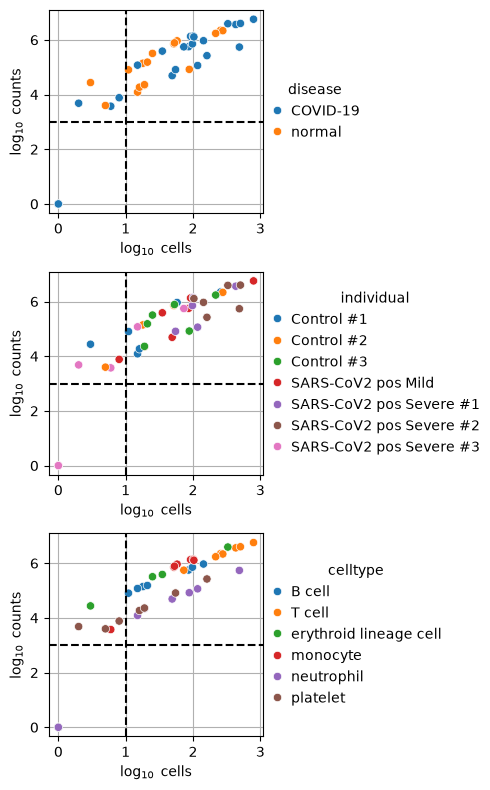

In [8]:
dc.pl.filter_samples(
    adata=pdata,
    groupby=["disease", "individual", "celltype"],
    min_cells=10,
    min_counts=1000,
    figsize=(5, 8),
)

As a general rule of thumb, low-quality samples can be filtered out based on the number of cells, and how many gene counts they have

In [9]:
dc.pp.filter_samples(pdata, min_cells=10, min_counts=1000)

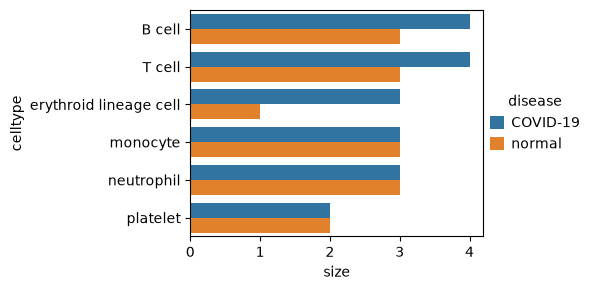

In [10]:
dc.pl.obsbar(adata=pdata, y="celltype", hue="disease", figsize=(6, 3))

## Exploring the psuedobulk data
With the pseudobulk profiles generated for each individual and cell type, let's explore

In [11]:
# store counts into their own layer again
pdata.layers['counts'] = pdata.X.copy()

# Normalize, scale, and PCA
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)
sc.tl.pca(pdata)

# Reassign the raw counts back to X
dc.pp.swap_layer(pdata, key='counts', inplace=True)

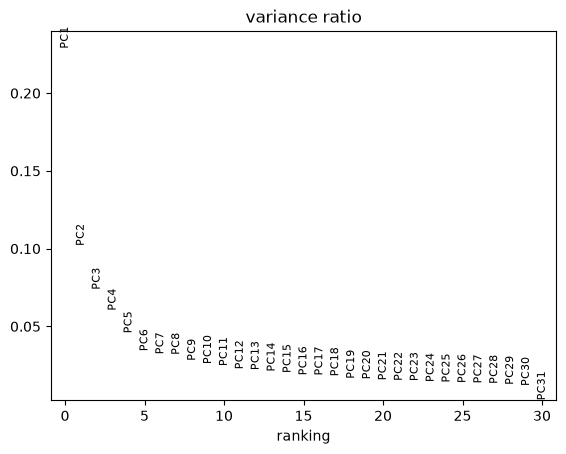

In [12]:
sc.pl.pca_variance_ratio(pdata)

We can rank PCA features by the significance of their association with labels in `adata.obs`. `dc.tl.rankby_obsm` uses ANOVA for association with categorical labels, and Spearman's correlation for association with continuous values.

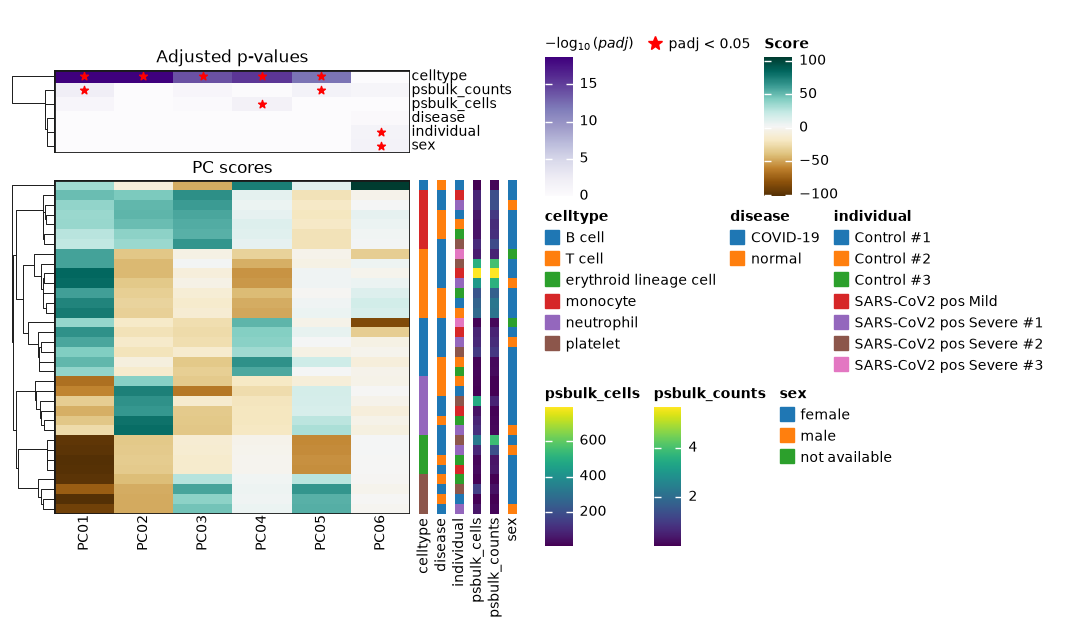

In [13]:
dc.tl.rankby_obsm(pdata, key='X_pca')
dc.pl.obsm(pdata, return_fig=True, nvar=6, titles=["PC scores", "Adjusted p-values"], figsize=(10, 5))

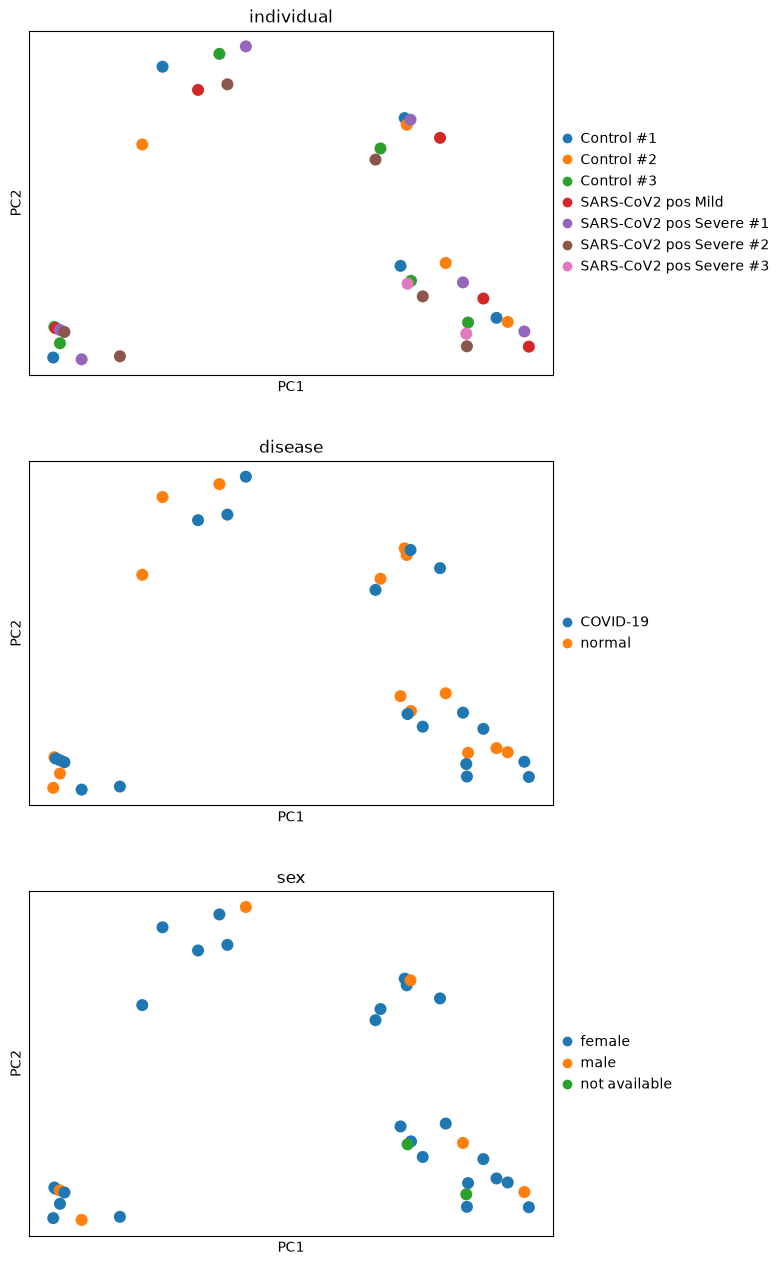

In [14]:
sc.pl.pca( 
    pdata,
    color=["individual", "disease", "sex"],
    ncols=1,
    size=300,
    frameon=True,
)

Well, these results aren't similar at all to what's in the tutorial. PC1 seems to only correlate strongly with celltype, and not disease and individual...

## Feature selection  for specific cell types

Let's look at the effects of COVID-19 on T cells, for this example

In [15]:
tcells = pdata[pdata.obs['celltype'] == 'T cell'].copy()
tcells

AnnData object with n_obs × n_vars = 7 × 20522
    obs: 'individual', 'celltype', 'sex', 'disease', 'psbulk_cells', 'psbulk_counts'
    var: 'gene_symbols', 'gene_name', 'mean', 'std'
    uns: 'log1p', 'pca', 'rank_obsm', 'individual_colors', 'disease_colors', 'sex_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', None (.X), 'counts', 'X'

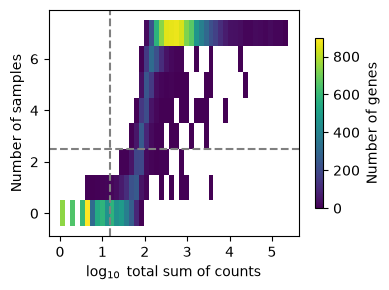

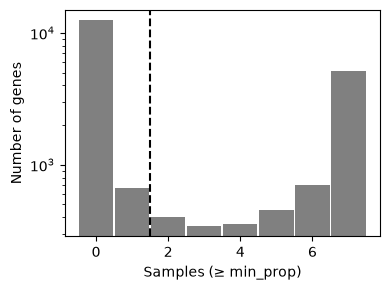

In [16]:
dc.pl.filter_by_expr(
    adata=tcells,
    group="disease",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
)
dc.pl.filter_by_prop(
    adata=tcells,
    min_prop=0.1,
    min_smpls=2,
)

Visually this shows 2 methods for retaining sets of genes. The first uses 2 thresholds - retain genes with a minimum total reads across all samples (min_total_count), and retain genes with a mimum number of counts in a given number of cells (min_count).

The second method is to retain genes expressed in a specified proportion of cells across a minimum number of samples.

In [17]:
dc.pp.filter_by_expr(
    adata=tcells,
    group="disease",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
)
dc.pp.filter_by_prop(
    adata=tcells,
    min_prop=0.1,
    min_smpls=2,
)
tcells

AnnData object with n_obs × n_vars = 7 × 7368
    obs: 'individual', 'celltype', 'sex', 'disease', 'psbulk_cells', 'psbulk_counts'
    var: 'gene_symbols', 'gene_name', 'mean', 'std'
    uns: 'log1p', 'pca', 'rank_obsm', 'individual_colors', 'disease_colors', 'sex_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', None (.X), 'counts', 'X'

## Differential Expression Analysis

Here, we'll use the python implementation of DESeq2.

In [18]:
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

# Build DESeq2 object
inference = DefaultInference()
dds = DeseqDataSet(
    adata=tcells,
    design="~disease + sex",
    refit_cooks=True,
    inference=inference
)

# Run DESeq
dds.deseq2()

Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 1.28 seconds.

Fitting dispersion trend curve...
C:\Users\CT\Documents\post_phd_training\omics_sandbox_venv\Lib\site-packages\pydeseq2\dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.31 seconds.

C:\Users\CT\Documents\post_phd_training\omics_sandbox_venv\Lib\site-packages\pydeseq2\dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 1.52 seconds.

Fitting LFCs...
... done in 1.06 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



In [19]:
# Next, extract statistics between conditions
stat_res = DeseqStats(dds, contrast=['disease', 'COVID-19', 'normal'], inference=inference)

# Compute Wald test
stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: disease COVID-19 vs normal
                    baseMean  log2FoldChange     lfcSE      stat    pvalue  \
MTND1P23         2082.257009        3.221043  1.004128  3.207801  0.001338   
MTND2P28           83.113791       -1.024769  0.357043 -2.870157  0.004103   
MTCO1P12           32.338428        0.099610  0.976502  0.102007  0.918751   
SKI                57.621415        0.074293  0.354583  0.209521  0.834041   
LZIC               74.408884        0.407610  0.343304  1.187315  0.235103   
...                      ...             ...       ...       ...       ...   
ENSG00000276794    33.392944       -0.396784  0.409053 -0.970007  0.332043   
ENSG00000273656   143.803975       -0.725632  0.357093 -2.032054  0.042148   
WASH3P             66.111614       -0.088061  0.368629 -0.238887  0.811193   
ENSG00000273673  3870.956240       -0.114798  0.300834 -0.381601  0.702757   
MPHOSPH10P9-1      38.838809       -0.007024  0.384063 -0.018288  0.985409   

... done in 0.53 seconds.



In [20]:
results_df = stat_res.results_df
results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
MTND1P23,2082.257009,3.221043,1.004128,3.207801,0.001338,0.205461
MTND2P28,83.113791,-1.024769,0.357043,-2.870157,0.004103,0.392734
MTCO1P12,32.338428,0.099610,0.976502,0.102007,0.918751,0.996388
SKI,57.621415,0.074293,0.354583,0.209521,0.834041,0.996388
LZIC,74.408884,0.407610,0.343304,1.187315,0.235103,0.996388
...,...,...,...,...,...,...
ENSG00000276794,33.392944,-0.396784,0.409053,-0.970007,0.332043,0.996388
ENSG00000273656,143.803975,-0.725632,0.357093,-2.032054,0.042148,0.848491
WASH3P,66.111614,-0.088061,0.368629,-0.238887,0.811193,0.996388
ENSG00000273673,3870.956240,-0.114798,0.300834,-0.381601,0.702757,0.996388


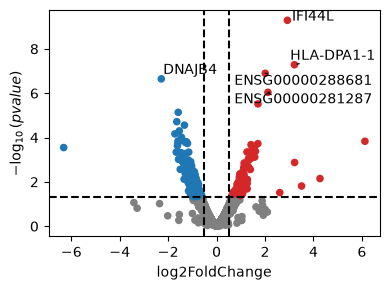

In [21]:
dc.pl.volcano(results_df, x="log2FoldChange", y="pvalue") # Wahoo, volcano plot from the data!

Now that we've performed the differential expression analysis, we can use the gene-level statistics for enrichment analysis.

Let's use the t-values

In [22]:
data = results_df[["stat"]].T.rename(index={"stat": "disease.vs.normal"})
data

,MTND1P23,MTND2P28,MTCO1P12,SKI,LZIC,ENO1,PLEKHM2,DHRS3,NMNAT1,MTATP6P1,...,TINF2,RUVBL1-1,STING1,ENSG00000275495,HERC2P9-1,ENSG00000276794,ENSG00000273656,WASH3P,ENSG00000273673,MPHOSPH10P9-1
disease.vs.normal,3.207801,-2.870157,0.102007,0.209521,1.187315,1.513385,-0.916208,-1.876839,0.066089,-4.272994,...,0.401621,0.491046,2.113352,0.061214,0.037955,-0.970007,-2.032054,-0.238887,-0.381601,-0.018288


## Enrichment Analysis

### First, let's score TFs using CollecTRI network

In [23]:
collectri = dc.op.collectri(organism='human')
collectri

,source,target,weight,resources,references,sign_decision
0,MYC,TERT,1.0,DoRothEA-A;ExTRI;HTRI;NTNU.Curated;Pavlidis202...,10022128;10491298;10606235;10637317;10723141;1...,PMID
1,SPI1,BGLAP,1.0,ExTRI,10022617,default activation
2,SMAD3,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
3,SMAD4,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
4,STAT5A,IL2,1.0,ExTRI,10022878;11435608;17182565;17911616;22854263;2...,default activation
...,...,...,...,...,...,...
42985,NFKB,hsa-miR-143-3p,1.0,ExTRI,19472311,default activation
42986,AP1,hsa-miR-206,1.0,ExTRI;GEREDB;NTNU.Curated,19721712,PMID
42987,NFKB,hsa-miR-21,1.0,ExTRI,20813833;22387281,default activation
42988,NFKB,hsa-miR-224-5p,1.0,ExTRI,23474441;23988648,default activation


In [24]:
tf_acts, tf_padj = dc.mt.ulm(data, net=collectri)

# Filter by the sign of padj
mask = (tf_padj.T < 0.05).iloc[:, 0]
tf_acts = tf_acts.loc[:, mask]

tf_acts

,ATF1,ATF2,BMAL1,BMAL2,CLOCK,DMTF1,E2F4,EOMES,EP300,HIVEP2,...,JUND,MYC,NFKB,NFKB1,NKX2-5,NOTCH1,NR4A2,RELA,TBX21,ZGLP1
disease.vs.normal,-3.151559,-3.126762,-3.7623,-3.477303,-3.286145,-3.039046,3.119266,-3.65093,-3.255213,-3.994057,...,-3.514838,4.189834,-3.214711,-3.260561,-3.82245,-3.191368,-3.565885,-3.766365,-3.005412,-3.418689


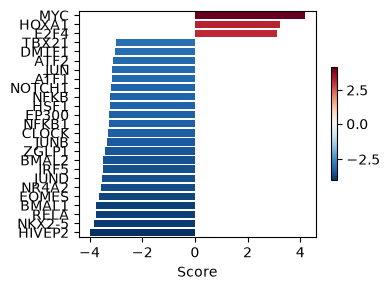

In [25]:
dc.pl.barplot(data=tf_acts, name="disease.vs.normal", figsize=(4, 3))

Well, I have the workflow down, but do I have the trends backwards? The tutorial seems to have Myc as heavily downregulated in the disease condition!

TODO: check if the original expression matrix (filtered expression) is the right one I should be using.

## Pathway scoring with Hallmark gene sets

In [26]:
hallmark = dc.op.hallmark(organism='human')

In [27]:
# Use a univariate linear model as we have done so far with all tutorials
hallmark_scores, hallmark_padj = dc.mt.ulm(data, net=hallmark)

mask = (hallmark_padj.T < 0.05).iloc[:, 0]
hallmark_scores = hallmark_scores.loc[:, mask]

hallmark_scores

,ADIPOGENESIS,DNA_REPAIR,E2F_TARGETS,FATTY_ACID_METABOLISM,G2M_CHECKPOINT,GLYCOLYSIS,INTERFERON_ALPHA_RESPONSE,INTERFERON_GAMMA_RESPONSE,MTORC1_SIGNALING,MYC_TARGETS_V1,MYC_TARGETS_V2,MYOGENESIS,OXIDATIVE_PHOSPHORYLATION,PEROXISOME,REACTIVE_OXYGEN_SPECIES_PATHWAY,TGF_BETA_SIGNALING,TNFA_SIGNALING_VIA_NFKB
disease.vs.normal,4.059038,3.988775,7.268715,5.520724,3.513268,3.22644,7.698127,4.4603,3.387392,10.62192,3.540745,-2.466255,9.452918,3.139849,2.607182,-2.551829,-10.727979


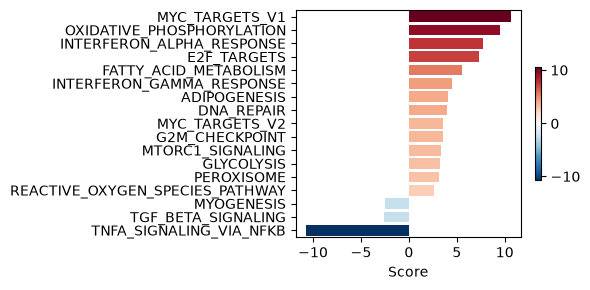

In [29]:
dc.pl.barplot(hallmark_scores, name='disease.vs.normal', figsize=(6,3))

Using the results from running PyDESeq, we can even visualize a leading edge plot

None
leading edge:  ['PCNA' 'MYC' 'YWHAE' 'MCM5' 'NME1']


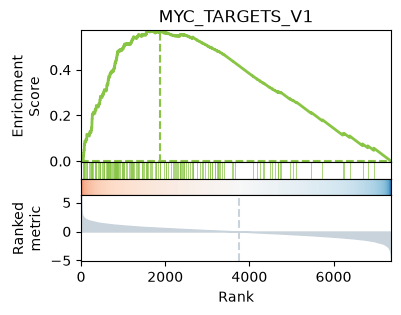

In [30]:
test, le = dc.pl.leading_edge(
    results_df,
    stat='stat',
    net=hallmark,
    name='MYC_TARGETS_V1'
)

print(test)
print('leading edge: ', le[:5])

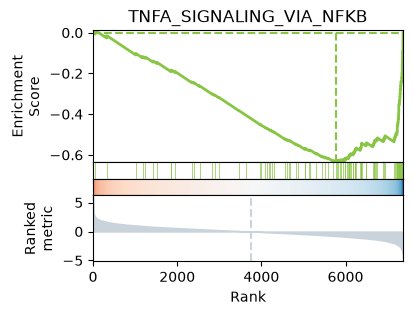

In [78]:
test, le = dc.pl.leading_edge(
    results_df,
    stat='stat',
    net=hallmark,
    name='TNFA_SIGNALING_VIA_NFKB'
)


Yea..... I seem to have the trend backwards compared to the tutorial code!

## Debugging why my gene expression trends are opposite of the tutorials
The only thing I think is different from the original tutorial code is where I got the data. Because decoupler's native function for pulling the covid5k dataset gave an Error 404, I downloaded the project h5ad myself, and worked with that data.

Let's confirm that genes associated for example, MYC targets and TNFA_SIGNALING are actually expressed in the right directions (based on expression counts, not any downstream DESeq or decoupler analysis)

In [40]:
pdata

AnnData object with n_obs × n_vars = 34 × 20522
    obs: 'individual', 'celltype', 'sex', 'disease', 'psbulk_cells', 'psbulk_counts'
    var: 'gene_symbols', 'gene_name', 'mean', 'std'
    uns: 'log1p', 'pca', 'rank_obsm', 'individual_colors', 'disease_colors', 'sex_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', None (.X), 'counts', 'X'

### Myc first

The leading edge of the MYC targets geneset for disease.vs.normal was ['PCNA' 'MYC' 'YWHAE' 'MCM5' 'NME1']

In [50]:
adata_b

AnnData object with n_obs × n_vars = 4903 × 20522
    obs: 'individual', 'sex', 'disease', 'celltype'
    var: 'gene_symbols', 'gene_name'
    uns: 'celltype_colors', 'disease_colors'
    obsm: 'X_umap'
    layers: None (.X)

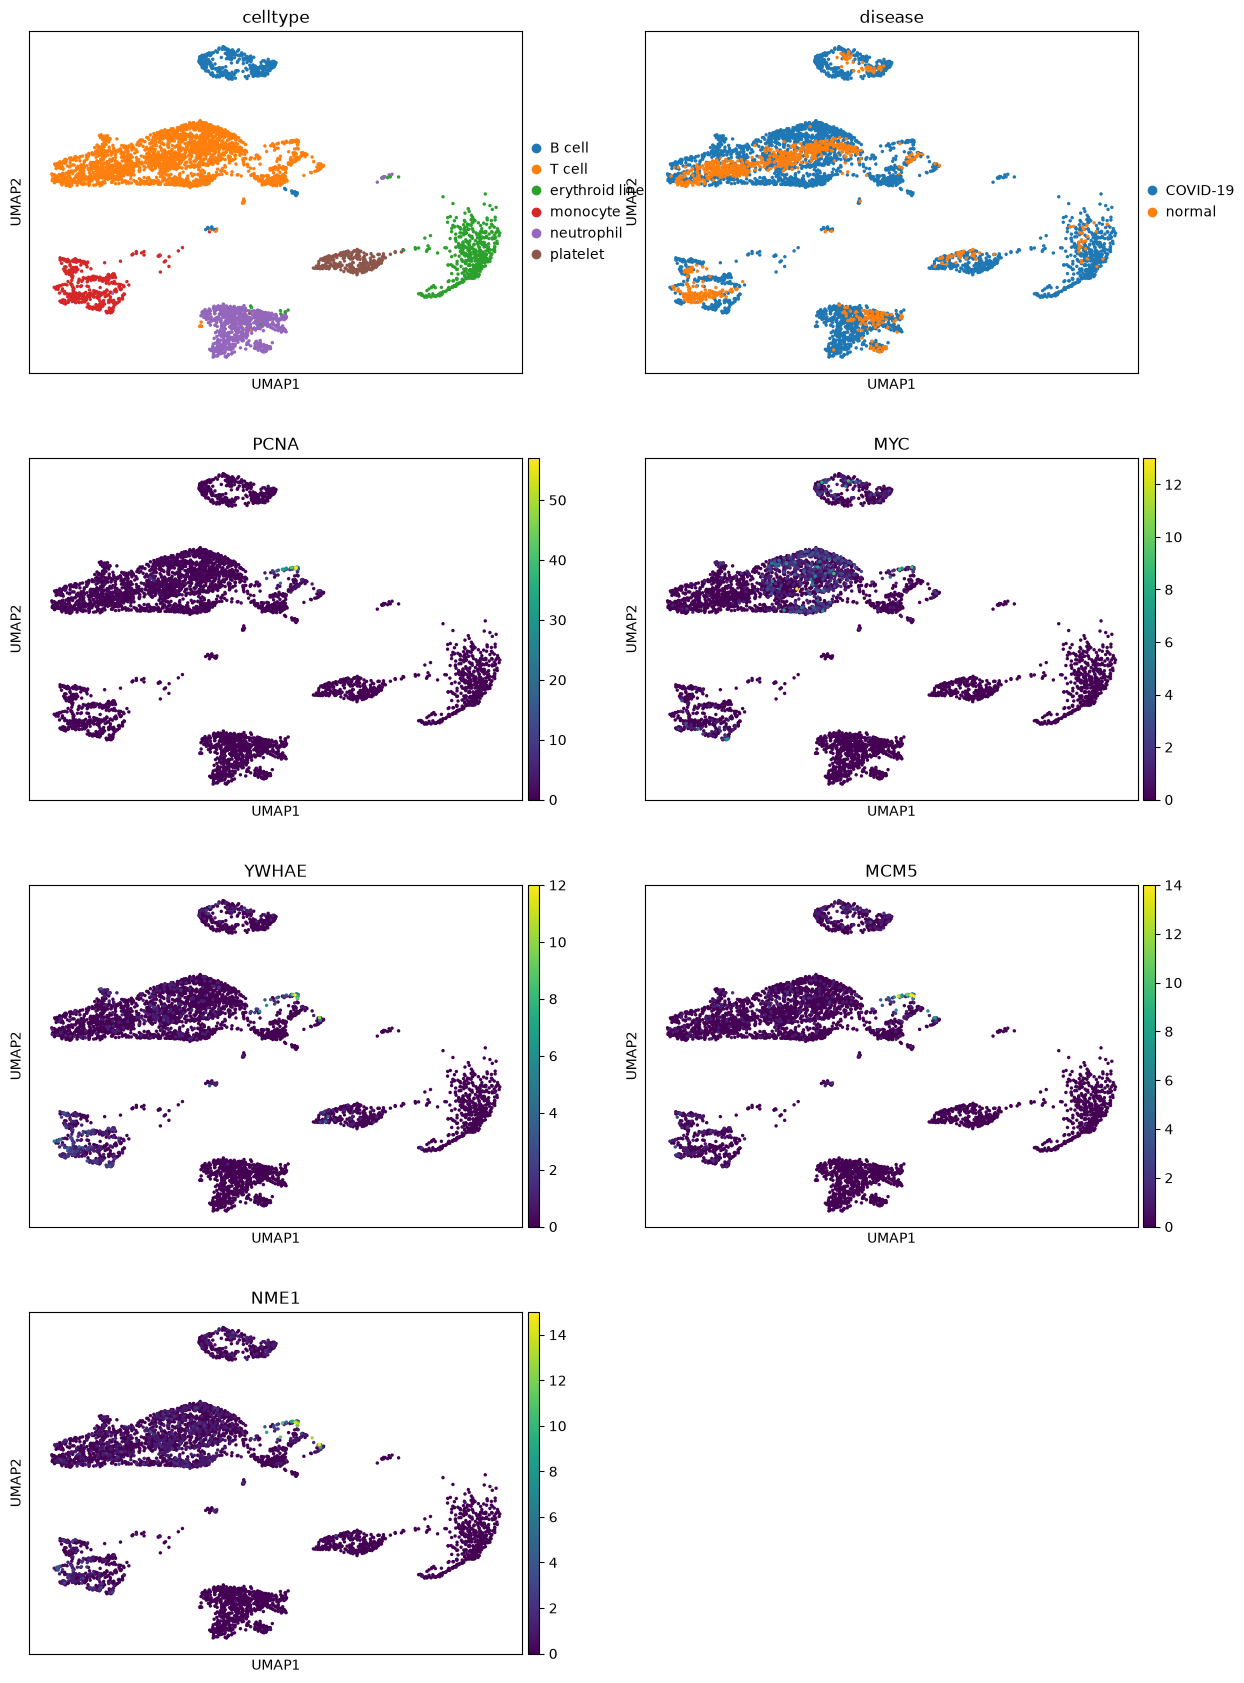

In [55]:
myc_genes_sample_set = ['PCNA', 'MYC', 'YWHAE', 'MCM5', 'NME1']

sc.pl.umap(adata_b, color=['celltype', 'disease'] + myc_genes_sample_set, ncols=2)

In [71]:
tcell_mask = (pdata.obs['celltype'] == 'T cell')
sub_df = pdata[tcell_mask, myc_genes_sample_set]

#sub_df.var_names
pd.DataFrame(sub_df.X, index=sub_df.obs.index, columns=sub_df.var_names)

,PCNA,MYC,YWHAE,MCM5,NME1
Control #1_T cell,30.0,69.0,19.0,17.0,61.0
Control #2_T cell,78.0,60.0,23.0,25.0,29.0
Control #3_T cell,37.0,54.0,18.0,21.0,51.0
SARS-CoV2 pos Mild_T cell,204.0,341.0,79.0,84.0,184.0
SARS-CoV2 pos Severe #1_T cell,373.0,208.0,73.0,145.0,174.0
SARS-CoV2 pos Severe #2_T cell,272.0,186.0,102.0,105.0,239.0
SARS-CoV2 pos Severe #3_T cell,18.0,62.0,7.0,13.0,24.0


So, based on these pseudobulk counts, the control T-cells are DOWNREGULATING Myc targets (with the exception of T-cell group #2)

Huh? How'd this diverge from the tutorial's plots for Myc targets?

### TNFA signaling next
In the tutorial, TNFA_SIGNALING is postively enriched for in the disease condition. According to the leading edge plot there, the first genes are ['NR4A2' 'JUN' 'SQSTM1' 'JUNB' 'IER5']

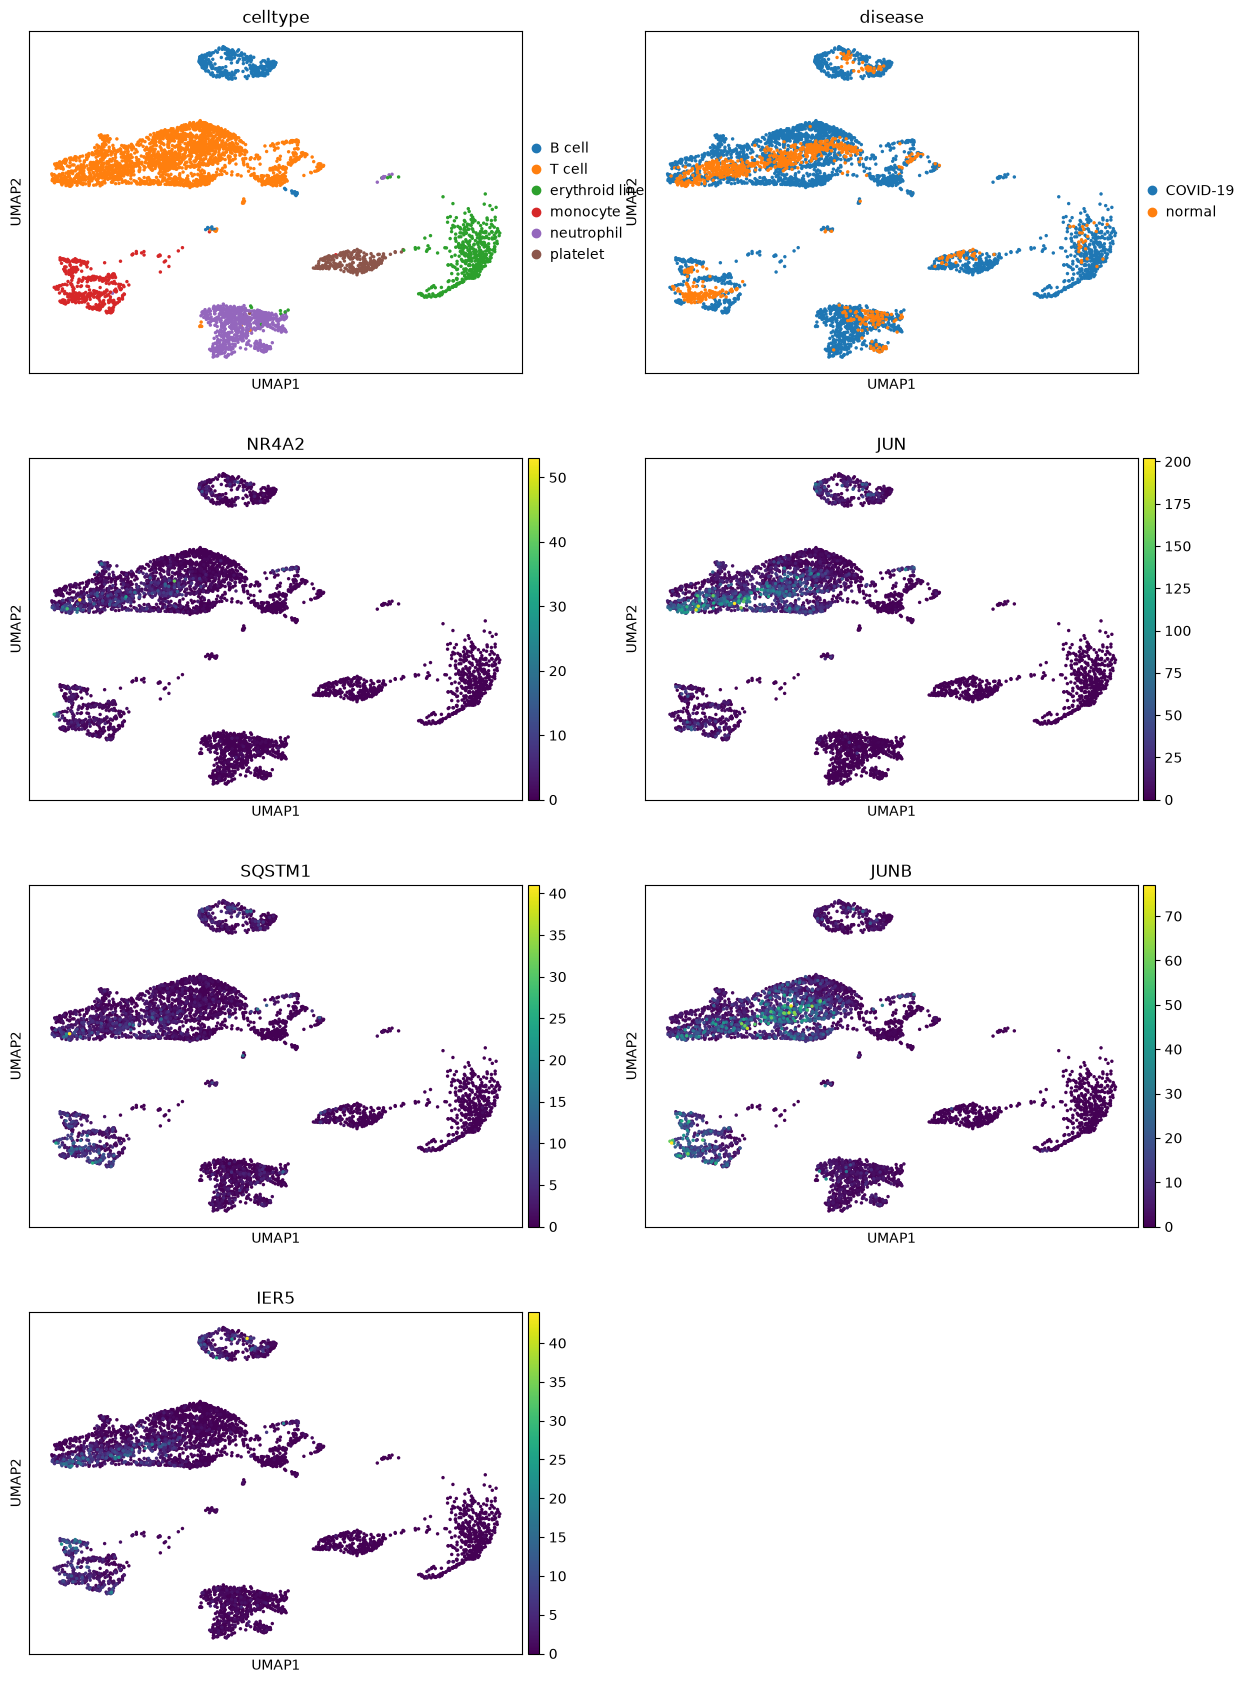

In [80]:
tnfa_genes_sample_set = ['NR4A2', 'JUN', 'SQSTM1', 'JUNB', 'IER5']

sc.pl.umap(adata_b, color=['celltype', 'disease'] + tnfa_genes_sample_set, ncols=2)

In [81]:
tcell_mask = (pdata.obs['celltype'] == 'T cell')
sub_df = pdata[tcell_mask, tnfa_genes_sample_set]

#sub_df.var_names
pd.DataFrame(sub_df.X, index=sub_df.obs.index, columns=sub_df.var_names)

,NR4A2,JUN,SQSTM1,JUNB,IER5
Control #1_T cell,657.0,6746.0,414.0,3155.0,526.0
Control #2_T cell,571.0,8168.0,394.0,2877.0,751.0
Control #3_T cell,479.0,3951.0,255.0,1726.0,435.0
SARS-CoV2 pos Mild_T cell,608.0,5952.0,413.0,3887.0,372.0
SARS-CoV2 pos Severe #1_T cell,603.0,6207.0,350.0,3021.0,310.0
SARS-CoV2 pos Severe #2_T cell,525.0,7283.0,425.0,3071.0,482.0
SARS-CoV2 pos Severe #3_T cell,14.0,313.0,15.0,460.0,6.0


In [82]:
results_df.loc[tnfa_genes_sample_set, :]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
NR4A2,416.745691,-1.201002,0.321230,-3.738759,0.000185,0.069589
JUN,4681.681765,-1.030215,0.372473,-2.765876,0.005677,0.459651
SQSTM1,269.525062,-0.906890,0.341556,-2.655170,0.007927,0.513305
JUNB,2266.589879,-0.751519,0.318554,-2.359158,0.018316,0.695688
IER5,368.386312,-1.538769,0.379495,-4.054781,0.000050,0.036974


JUN, SQSTM1, and JUNB are non-significant when comparing diseased v/s normal T-cells. The other two genes which are significant are DOWNREGULATED in the disease condition...

I guess at this point, I think I will say that because I and the tutorial started from not exactly the same expression counts, our results deviated. All code basically matched theirs, so while I am still quite puzzled at how I'm getting different results in the end, I still learned how to use decoupler to perform pseudobulk analysis and enrichment analysis!

I guess I'll take that as a win....